# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: XX     |  |
| :-------------|:-------------|
| Amun Gomperts| 6557309 |
| Hugo van Krevel| 6578993 |

In [4]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

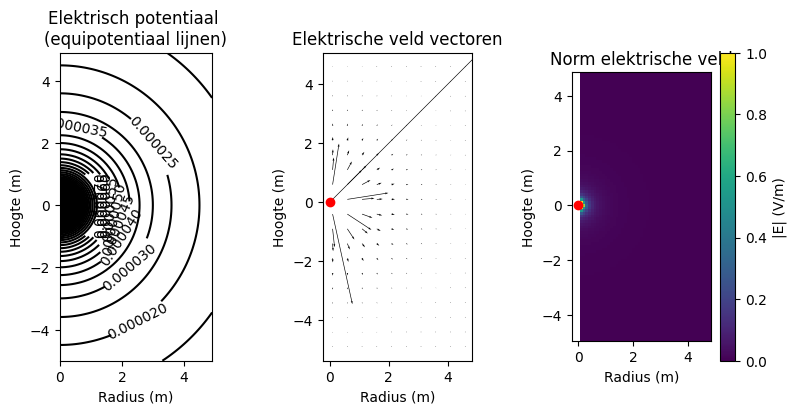

In [5]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

index closest to zero equals 50


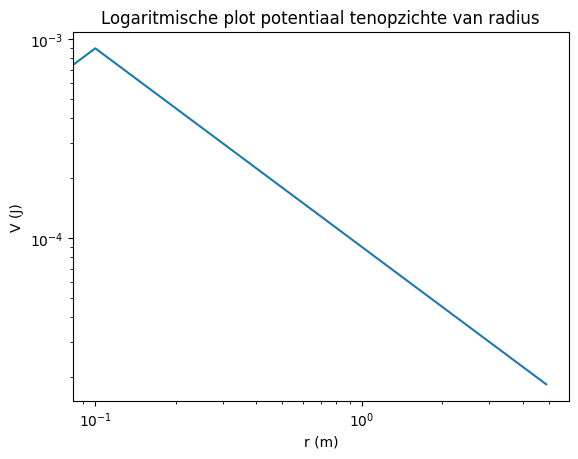

de gevonden exponent is -14


In [6]:
###
from scipy.optimize import curve_fit
###Hier jouw code###
indx_z_0 = np.argmin(z**2)
print("index closest to zero equals",indx_z_0)

plt.figure()
plt.title("Logaritmische plot potentiaal tenopzichte van radius")
plt.loglog(r,V[indx_z_0,:])
plt.xlabel("r (m)")
plt.ylabel("V (J)")
plt.show()

def V_op_z0(r, charge_one_point):
    xc = 0
    yc = 0
    zc = 0
    r_charge = np.array([xc,yc,zc])
    return electric_potential_point_charge_cartesian(r_charge, r, z[indx_z_0], charge_one_point)
value_V, fout_V = curve_fit(V_op_z0,r,V[indx_z_0,:])
print("de gevonden exponent is",round(np.log10(value_V[0])))
###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

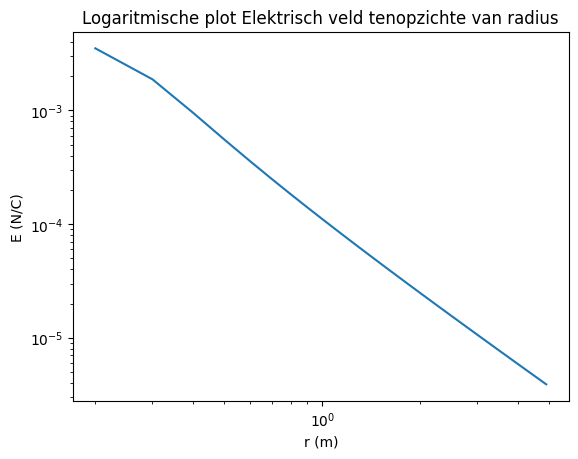

In [7]:
###
plt.figure()
plt.title("Logaritmische plot Elektrisch veld tenopzichte van radius")
plt.loglog(r[2:],normE[indx_z_0,:])
plt.xlabel("r (m)")
plt.ylabel("E (N/C)")
plt.show()

def E_curvefit(V,B):
    return compute_E_pt_charge(V, B, grid_step)
Er_z0, Ez_z0, normE_z0 = E_curvefit(V, B)

#value_E, fout_E = curve_fit(E_curvefit, V[indx_z_0,:], normE_z0[indx_z_0,:])
#print("de gevonden exponent is",round(np.log10(value_E[0])))
####

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [8]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

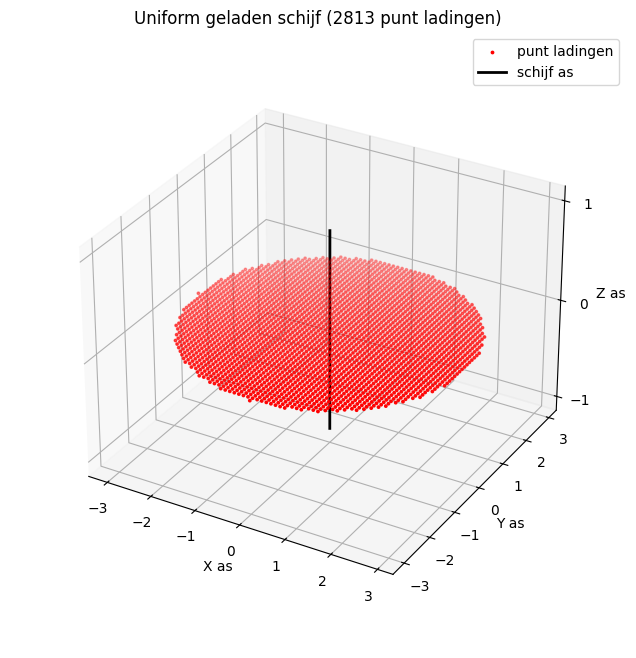

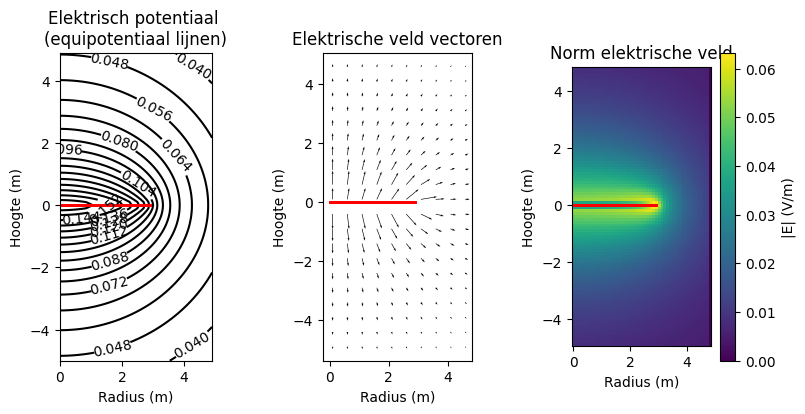

In [9]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a
1. De straal van de geladen schijf
2. de afstand die de puntladingen van elkaar hebben
3. z_coord_DISK veranderd de hoogte van het potentiaal en de lijnen in het E-veld

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [10]:
###
###Hier jouw code###
###
print(charge_one_point, number_point_charges_on_disk)
#De straal is 3 m, de lading van elke individuele punt is  10^-14 en er zijn 2813 punten
sigma= 2813*10**-14/(np.pi*3**2)
print("de oppervlakte ladingsdichtheid is",sigma,"C/m^2")

1e-14 2813
de oppervlakte ladingsdichtheid is 9.948952331500036e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

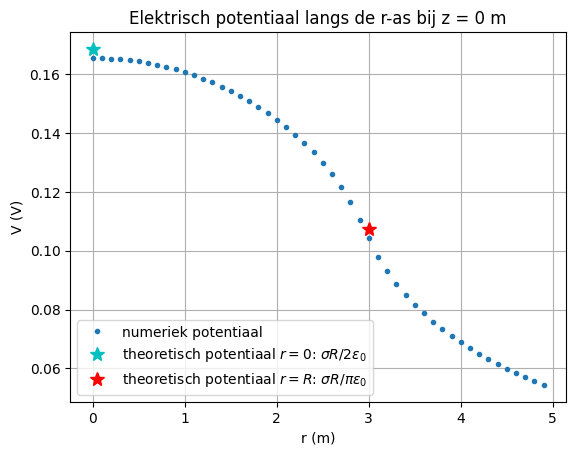

In [11]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = find_idx_nearest(z,0)

V_0 = sigma * disk_radius / (2 * epsilon0)          # potentiaal in het centrum (r = 0)
V_R = sigma * disk_radius / (np.pi * epsilon0)       # potentiaal op de rand (r = R)
r_R = disk_radius                                      # straal van de schijf

plt.figure()
plt.title("Elektrisch potentiaal langs de r-as bij z = 0 m")
plt.plot(r,V[idx_z_zero,:], ".", label="numeriek potentiaal")
plt.plot(0, V_0, "c*", markersize=10, label=r"theoretisch potentiaal $r=0$: $\sigma R / 2\epsilon_0$")
plt.plot(r_R, V_R, "r*", markersize=10, label=r"theoretisch potentiaal $r=R$: $\sigma R / \pi\epsilon_0$")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("V (V)")
plt.grid(True)
plt.show()


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


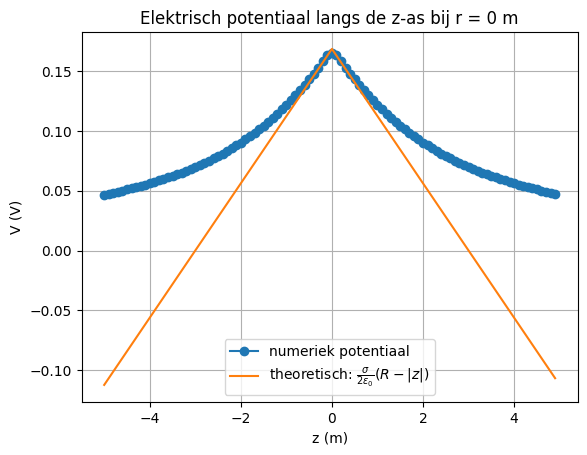

In [12]:
###
###Hier jouw code###
###

idx_r_zero = find_idx_nearest(r, 0)

# Theoretisch potentiaal op de z-as
V_theory_z = sigma / (2 * epsilon0) * (disk_radius - np.abs(z))

plt.figure()
plt.title("Elektrisch potentiaal langs de z-as bij r = 0 m")
plt.plot(z, V[:, idx_r_zero].squeeze(), "o-", label="numeriek potentiaal")
plt.plot(z, V_theory_z, "-", label=r"theoretisch: $\frac{\sigma}{2\epsilon_0}(R - |z|)$")
plt.legend()
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.grid(True)
#plt.savefig("potentiaal_z_as_r3.png", dpi=150, bbox_inches="tight")
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

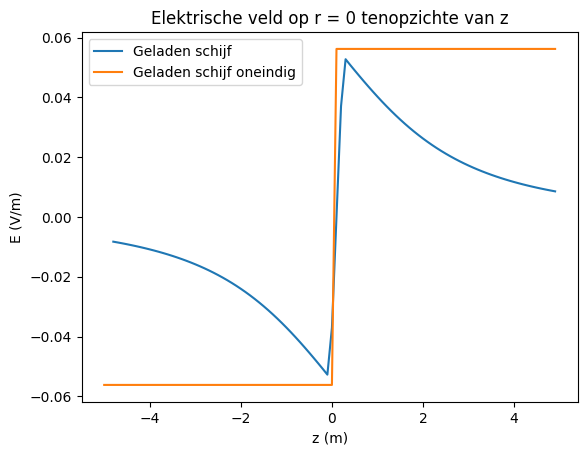

In [13]:
###
###Hier jouw code###

E_field = sigma/(2*epsilon0)*np.sign(z)

plt.figure()
plt.title("Elektrische veld op r = 0 tenopzichte van z")
plt.plot(z[2:], Ez[:, idx_r_zero], label = "Geladen schijf")
plt.plot(z, E_field, label = "Geladen schijf oneindig")
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.legend()
#plt.savefig("E_veld_z_ass_r3.png", dpi=150, bbox_inches="tight")
plt.show()
###

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Dicht bij de schijf, dus waar $|z| \ll R$. In dat geval "ziet" een punt op de z-as de schijf als nagenoeg oneindig groot, en geldt $E \approx \sigma/2\epsilon_0$.
2. Dicht bij de schijf komt het numerieke veld goed overeen met de theoretische waarde $\sigma/2\epsilon_0$, wat verwacht is omdat de benadering $R \gg |z|$ hier geldig is. Ver van de schijf wijkt het numerieke veld sterk af en wordt veel kleiner dan de theoretische waarde. Dit komt doordat onze schijf een eindige straal $R = 3$ m heeft, waardoor een punt ver weg de schijf als steeds kleiner ervaart en het veld afneemt. Een echte oneindige plaat zou dit effect niet hebben. Tot slot is er een discontinuïteit bij $z = 0$, waar het veld springt van $+\sigma/2\epsilon_0$ naar $-\sigma/2\epsilon_0$. Dit is fysisch correct, want het elektrische veld van een oppervlaktelading is discontinu ter hoogte van het oppervlak, met een totale sprong van $\sigma/\epsilon_0$.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

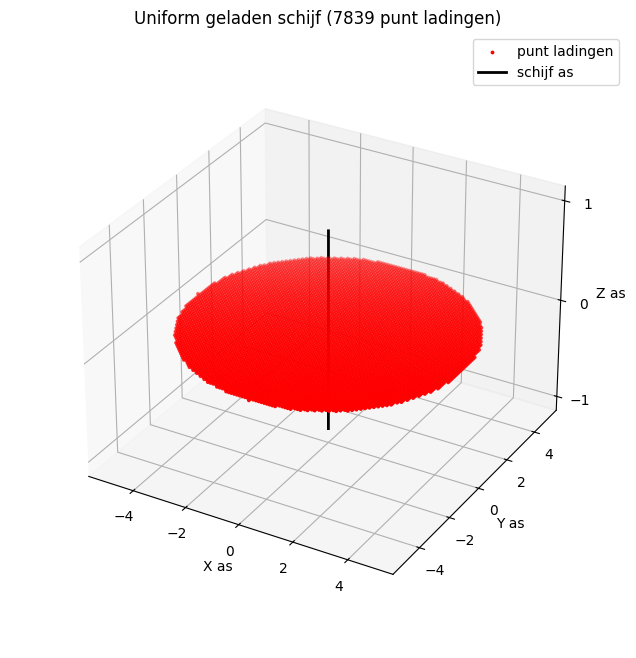

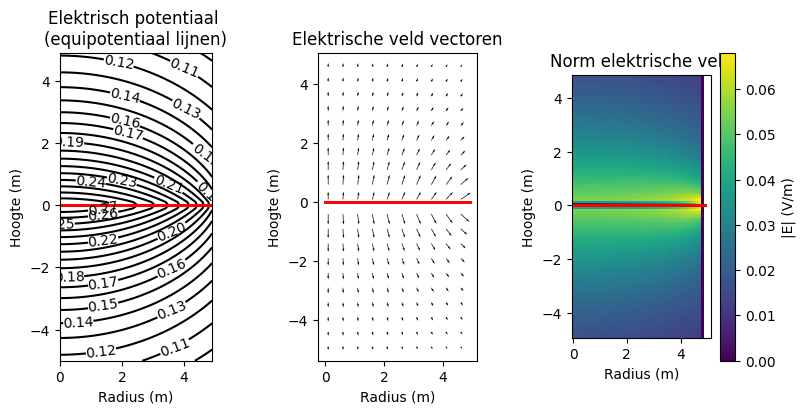

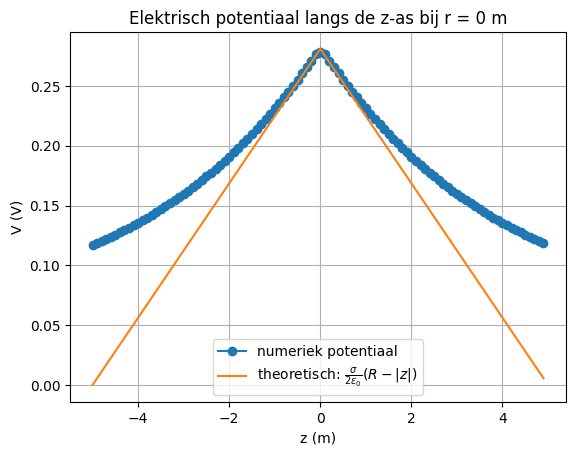

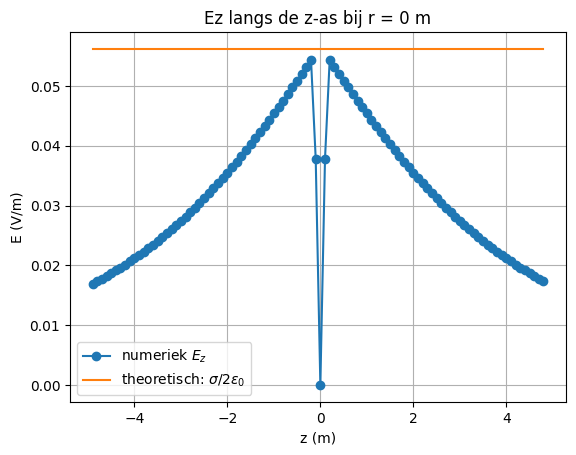

In [14]:
###
###Jouw code hier###
###

disk_radius = 5  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

idx_r_zero = find_idx_nearest(r, 0)

# Theoretisch potentiaal op de z-as
V_theory_z = sigma / (2 * epsilon0) * (disk_radius - np.abs(z))

plt.figure()
plt.title("Elektrisch potentiaal langs de z-as bij r = 0 m")
plt.plot(z, V[:, idx_r_zero].squeeze(), "o-", label="numeriek potentiaal")
plt.plot(z, V_theory_z, "-", label=r"theoretisch: $\frac{\sigma}{2\epsilon_0}(R - |z|)$")
plt.legend()
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.grid(True)
plt.savefig("potentiaal_z_as2.png", dpi=150, bbox_inches="tight")
plt.show()

idx_r_zero_E = find_idx_nearest(r_for_E, 0)

# Theoretisch elektrisch veld oneindig oppervlak
E_theory = sigma / (2 * epsilon0) * np.ones_like(z_for_E)

plt.figure()
plt.title("Ez langs de z-as bij r = 0 m")
plt.plot(z_for_E, np.abs(Ez[:, idx_r_zero_E].squeeze()), "o-", label="numeriek $E_z$")
plt.plot(z_for_E, E_theory, "-", label=r"theoretisch: $\sigma / 2\epsilon_0$")
plt.legend()
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.grid(True)
plt.savefig("elektrisch_veld_z_as2.png", dpi=150, bbox_inches="tight")
plt.show()


##### Antwoorden 2g
3. 
elektrische veld
![Alt](E_veld_z_ass_r3.png "Elektrische veld straal van 3")
![Alt](E_veld_z_ass_r10.png "Elektrische veld straal van 10")
potentiaal
![Alt](potentiaal_z_as_r3.png "potentiaal straal van 3")
![Alt](potentiaal_z_as_r10.png "potentiaal straal van 10")
4.
je ziet dat de grotere straal dichterbij het theoretische oneindige vlak komt in beide gevallen.


#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

Het elektrische veld van een oneindige plaat is $E_\infty = \sigma/2\epsilon_0$. We zoeken de hoogte $z$ waarbij het veld van de schijf 10% is van dat van de oneindige plaat:

$$\frac{E(z)}{E_\infty} = 0.10$$

Dit geeft:

$$\frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right] = 0.10 \cdot \frac{\sigma}{2\epsilon_0}$$

De $\sigma/2\epsilon_0$ valt weg:

$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0.10$$

$$\frac{z}{\sqrt{R^2 + z^2}} = 0.90$$

Kwadrateer beide kanten:

$$\frac{z^2}{R^2 + z^2} = 0.81$$

$$z^2 = 0.81 (R^2 + z^2)$$

$$z^2 - 0.81 z^2 = 0.81 R^2$$

$$0.19 z^2 = 0.81 R^2$$

$$z = R\sqrt{\frac{0.81}{0.19}} = R\sqrt{\frac{81}{19}} \approx 2.06 \, R$$

Voor onze schijf met $R = 3$ m geeft dit $z \approx 6.19$ m.

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

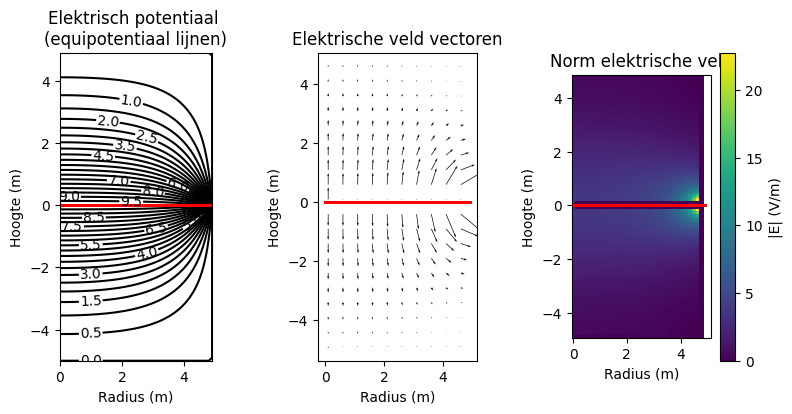

In [15]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

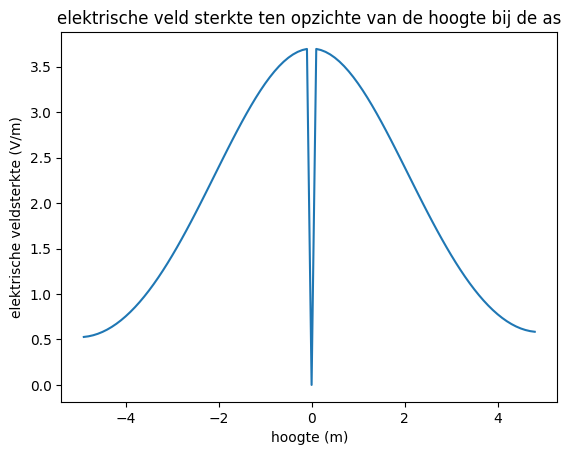

de norm van het elektrische veld op de as heel dichtbij het midden van de schijf is 6.04e-05 V/m


In [16]:
###

plt.figure()
plt.title("elektrische veld sterkte ten opzichte van de hoogte bij de as")
plt.plot(z[1:-1],normE[:,0])
plt.xlabel("hoogte (m)")
plt.ylabel("elektrische veldsterkte (V/m)")
plt.show()

idx_z_0 = find_idx_nearest(z,0)
normE_z0 = normE[idx_z_0-1,0]
print("de norm van het elektrische veld op de as heel dichtbij het midden van de schijf is", round(normE_z0,7), "V/m")
###

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

*Geef in deze markdown cel je antwoord op 3b.1.*

De oppervlaktelading $\sigma$ kan worden benaderd via de randvoorwaarde van het elektrische veld aan een geleidend oppervlak:

$$\sigma = \epsilon_0 E_\perp$$

waarbij $E_\perp$ de component van het elektrische veld loodrecht op het oppervlak is. Omdat de schijf in het $z=0$ vlak ligt, is dit de $z$-component van het veld. Omdat het veld aan beide kanten van de schijf bijdraagt geldt:

$$\sigma = \epsilon_0 (E_{z,\text{boven}} - E_{z,\text{onder}}) = 2\epsilon_0 E_z$$

waar we gebruik maken van de symmetrie van de opstelling ($E_{z,\text{boven}} = -E_{z,\text{onder}}$).

In [17]:
idx_r_zero_E = find_idx_nearest(r_for_E, 0)
idx_z_zero_E = find_idx_nearest(z_for_E, 0)

Ez_center = Ez[idx_z_zero_E, idx_r_zero_E]
sigma_center = 2 * epsilon0 * Ez_center

print(f"Benadering van de oppervlaktelading in het midden van de schijf: {sigma_center:.4e} C/m²")

Benadering van de oppervlaktelading in het midden van de schijf: 1.0698e-15 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


[5.69419306e-12]


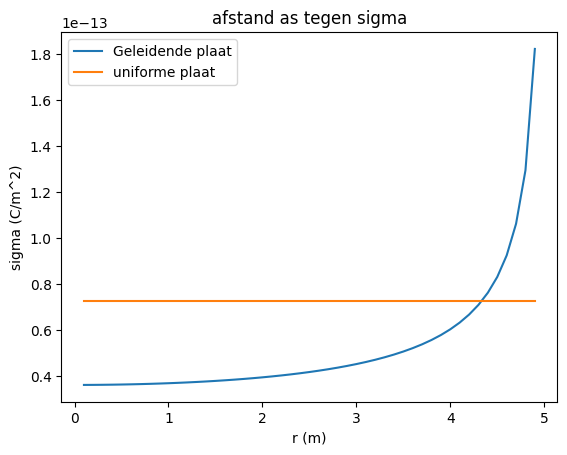

In [18]:
###
r_on_disk = r[1:len(r[r<disk_radius])]
normE_on_disk = normE[0,r[1:]<disk_radius]

def E_perp_fit(r,Q):
    R = disk_radius
    return Q/(2*np.pi*R*np.sqrt(R**2-r**2)*epsilon0)

value_Q , error_Q = curve_fit(E_perp_fit,r_on_disk, normE_on_disk)

print(value_Q)

def sigma_geleidend(r):
    Q = value_Q
    R = disk_radius
    return Q/(2*np.pi*R*np.sqrt(R**2-r**2))

A = np.pi*disk_radius**2
sigma_uniform = value_Q/A
sigma_uniform_array = np.ones(len(r_on_disk))*sigma_uniform

plt.title("afstand as tegen sigma")
plt.plot(r_on_disk, sigma_geleidend(r_on_disk), label="Geleidende plaat")
plt.plot(r_on_disk, sigma_uniform_array, label="uniforme plaat")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("sigma (C/m^2)")
plt.show()
###

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [19]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.
maximum_normE = np.max(normE)

print("de maximale norm van het elektrische veld is:", maximum_normE, "V/m")

def coord_value_finder_2D(array,value, axis1, axis2):
    idx = []
    for i in range(len(axis1)-2):
        for j in range(len(axis2)-1):
            if array[i,j] == value:
                idx.append([i,j])
                continue
            else:
                continue
    return idx

idx_max  = np.array(coord_value_finder_2D(normE,maximum_normE,z,r))
idx_z_max = idx_max[0,0]
idx_r_max = idx_max[0,1]
z_max = z[idx_z_max]
r_max = r[idx_r_max]

print("de hoogte hier van is",z_max,"m", "en de afstand vanaf de straal is",r_max,"m")

diff_max_mid = maximum_normE - normE_z0

print("het verschill in elektrische veld tussen het maximum en het midden is:", diff_max_mid, "V/m")
#

de maximale norm van het elektrische veld is: 22.767812288389493 V/m
de hoogte hier van is 0.09999999999998188 m en de afstand vanaf de straal is 4.6000000000000005 m
het verschill in elektrische veld tussen het maximum en het midden is: 22.76775187710242 V/m


##### Antwoord 3d.5
Het hoge elektrische veld aan de rand van de schijf wordt veroorzaakt door de concentratie van oppervlaktelading aan de rand. Zoals te zien in vraag 3c divergeert de oppervlakteladingsdichtheid $\sigma(r) \propto 1/\sqrt{R^2 - r^2}$ naar oneindig bij $r \to R$. Dit is een gevolg van het feit dat de schijf op een constant potentiaal gehouden wordt — ladingen herverdelen zich zo dat het potentiaal overal op de schijf gelijk is, wat leidt tot een ophoping aan de rand.

De elektronen in de plaat stoten elkaar af en bewegen dus naar de rand, hier is daardoor het maximum van de lading en dus ook het maximum van de norm van het elektrische veld.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

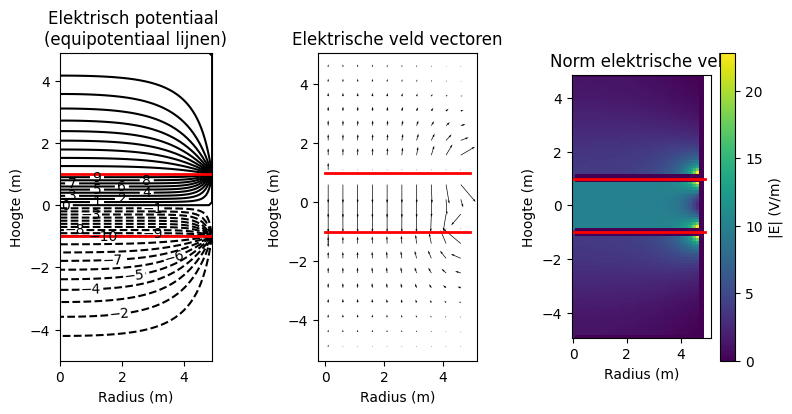

In [20]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


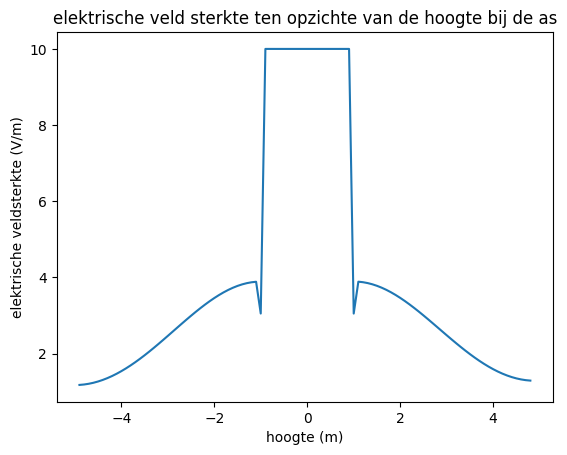

In [21]:
###
plt.figure()
plt.title("elektrische veld sterkte ten opzichte van de hoogte bij de as")
plt.plot(z[1:-1],normE[:,0])
plt.xlabel("hoogte (m)")
plt.ylabel("elektrische veldsterkte (V/m)")
plt.show()
###

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

![figure 5.1](figures/schets.jpg)

##### Antwoorden 4b

1. Theoretisch elektrisch veld tussen twee geleidende platen

Voor twee oneindige geleidende platen op potentiaal $V_1 = +10$ V en $V_2 = -10$ V met een onderlinge afstand $d$ geldt dat het potentiaal lineair varieert tussen de platen:

$$V(z) = V_1 - \frac{V_1 - V_2}{d} \cdot z$$

Het elektrische veld is de negatieve afgeleide van het potentiaal:

$$E_z = -\frac{dV}{dz} = \frac{V_1 - V_2}{d} = \frac{10 - (-10)}{2} = 10 \text{ V/m}$$

Er zijn drie regio's:

- **Regio I** ($z > z_1$, boven de bovenste schijf): $E \approx 0$, het veld dooft uit ver van de schijven.
- **Regio II** ($z_2 < z < z_1$, tussen de schijven): $E_z$ is constant en uniform, gericht van de positieve naar de negatieve plaat.
- **Regio III** ($z < z_2$, onder de onderste schijf): $E \approx 0$, het veld dooft uit ver van de schijven.


2. Vergelijking numeriek en theoretisch veld

Het numeriek berekende veld op de as komt grotendeels overeen met het theoretische veld. Tussen de schijven is $E_z$ nagenoeg constant, wat overeenkomt met de verwachting. Buiten de schijven neemt het veld snel af naar nul. Er zijn wel kleine afwijkingen doordat onze schijven een eindige straal hebben ($R = 3$ m) in plaats van oneindig, waardoor het veld aan de randen niet perfect uniform is.

3. Voordeel van twee schijven t.o.v. één schijf

Het elektrische veld tussen de twee schijven is significant sterker en uniformer dan dat van een enkele schijf op hetzelfde potentiaal. Bij een enkele schijf neemt het veld snel af met de afstand, terwijl twee tegengesteld geladen schijven het veld tussen hen in versterken en uniform houden. Dit is het werkingsprincipe van een **condensator**: door twee tegengesteld geladen platen tegenover elkaar te plaatsen ontstaat een sterk, uniform elektrisch veld in het gebied ertussen.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [22]:
###
delta_V = V1-V2

E_theor = delta_V/spacing_between_disks
E_sim = np.mean(Ez[(Ez >= z_pos_disk2) & (Ez <= z_pos_disk1)])

sigma_sim = E_sim*epsilon0
sigma_theor = E_theor*epsilon0

Q_sim = sigma_sim*np.pi*disk_radius**2
Q_theor = sigma_theor*np.pi*disk_radius**2

C_sim = Q_theor/delta_V
C_theor = Q_theor/delta_V

print("De verwachte oppervlakte lading op de binnenzijde van een van de schijven is:",sigma_theor, "De verwachte totale lading is:", 2*Q_theor,"En de verwachte capaciteit is:", C_theor)
print("De oppervlakte lading op de binnenzijde van een van de schijven is:",sigma_sim, "De totale lading is:", 2*Q_sim,"En de capaciteit is:", C_sim)
###

De verwachte oppervlakte lading op de binnenzijde van een van de schijven is: 8.853999999999999e-11 De verwachte totale lading is: 1.3907830677442012e-08 En de verwachte capaciteit is: 3.476957669360503e-10
De oppervlakte lading op de binnenzijde van een van de schijven is: 2.489600012146687e-12 De totale lading is: 3.910654554268546e-10 En de capaciteit is: 3.476957669360503e-10


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. Nee, de oppervlaktelading aan de buitenkant is niet exact nul, maar is wel veel kleiner dan aan de binnenkant. Dit komt doordat onze schijven een eindige straal hebben. Voor twee oneindige platen zou de buitenkant volledig vrij zijn van lading, omdat de velden van de twee platen elkaar buiten precies opheffen. Bij eindige schijven is deze opheffing niet perfect en lekt er een klein veld naar buiten (het "fringing field"), wat gepaard gaat met een kleine oppervlaktelading aan de buitenkant.

2. Het elektrische veld direct aan het oppervlak van een geleider staat altijd loodrecht op het oppervlak en heeft een grootte die gegeven wordt door :

$$E = \frac{\sigma}{\epsilon_0}$$

waarbij $\sigma$ de lokale oppervlakteladingsdichtheid is. Dit volgt direct uit de randvoorwaarden van Maxwell. Binnenin een geleider is het elektrische veld altijd nul, omdat vrije ladingen zich herverdelen totdat het nettoveld intern verdwijnt.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [23]:
idx_r_zero_E = find_idx_nearest(r_for_E, 0)

# 1. Ez net onder de onderste schijf (buitenkant)
idx_z_below_disk2 = find_idx_nearest(z_for_E, z_pos_disk2) - 1
Ez_below_disk2 = Ez[idx_z_below_disk2, idx_r_zero_E]

# 2. Ladingsdichtheid aan de onderkant van de onderste schijf
sigma_outer_disk2 = epsilon0 * Ez_below_disk2

# 3. Ez net boven de onderste schijf (binnenkant)
idx_z_above_disk2 = find_idx_nearest(z_for_E, z_pos_disk2) + 1
Ez_above_disk2 = Ez[idx_z_above_disk2, idx_r_zero_E]

# 4. Ladingsdichtheid aan de bovenkant van de onderste schijf
sigma_inner_disk2 = epsilon0 * Ez_above_disk2

# 5. Print
print(f"Het elektrisch veld Ez net onder de onderste schijf is {Ez_below_disk2:.4e} V/m, "
      f"wat overeenkomt met een ladingsdichtheid aan de buitenkant van de onderste schijf van {sigma_outer_disk2:.4e} C/m².\n")

print(f"Net boven de onderste schijf bedraagt Ez {Ez_above_disk2:.4e} V/m, "
      f"wat een ladingsdichtheid aan de binnenkant van de onderste schijf geeft van {sigma_inner_disk2:.4e} C/m².")

Het elektrisch veld Ez net onder de onderste schijf is 3.8878e+00 V/m, wat overeenkomt met een ladingsdichtheid aan de buitenkant van de onderste schijf van 3.4422e-11 C/m².

Net boven de onderste schijf bedraagt Ez -1.0000e+01 V/m, wat een ladingsdichtheid aan de binnenkant van de onderste schijf geeft van -8.8540e-11 C/m².


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f
-Uit vraag 4d en 4e blijkt dat er niet alleen lading aan de binnenkant van de schijven zit, maar ook een kleine hoeveelheid aan de buitenkant. In vraag 4c werd alleen de lading aan de binnenkant meegenomen in de berekening van $Q$. De daadwerkelijke totale lading op een schijf is dus de som van de lading aan de binnenkant en de buitenkant:

$$Q_{\text{totaal}} = Q_{\text{binnen}} + Q_{\text{buiten}}$$

In vraag 4c werd $Q_{\text{buiten}}$ verwaarloosd, waardoor de berekende lading en dus ook de capaciteit een onderschatting zijn van de werkelijke waarde.

-Omdat de werkelijke lading $Q_{\text{totaal}} > Q_{\text{binnen}}$ is, en de capaciteit gedefinieerd is als $C = Q/\Delta V$, betekent dit dat de werkelijke capaciteit groter is dan berekend in vraag 4c. Het verschil is echter klein zolang de buitenste ladingsdichtheid veel kleiner is dan de binnenste, wat het geval is wanneer de schijven dicht bij elkaar staan ten opzichte van hun straal.

-Bij een kleinere afstand tussen de schijven neemt het elektrische veld tussen de schijven toe, omdat $E = \Delta V / d$ en $\Delta V$ constant blijft terwijl $d$ kleiner wordt. Dit leidt tot een hogere oppervlakteladingsdichtheid aan de binnenkant en dus een grotere totale lading $Q$. Omdat $C = Q/\Delta V$ neemt de capaciteit toe bij een kleinere afstand. Dit klopt met de theoretische formule voor een vlakkeplaatcondensator:

$$C = \epsilon_0 \frac{A}{d}$$

waarbij $A$ het oppervlak van de schijf is en $d$ de afstand tussen de schijven. Een kleinere $d$ geeft dus een grotere capaciteit.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [24]:
def vlakkeplaat(A, d, epsilon):
    C = epsilon*A/d
    return C

def cilinder(R_in, R_out, L, epsilon):
    C = 2*np.pi*epsilon*L/(np.log(R_out/R_in))
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [25]:
###
A_1 = 0.1*0.1
d_1 = 0.001
epsilon_air = 1.0056*epsilon0
C_1 = vlakkeplaat(A_1, d_1, epsilon_air)
print("de capaciteit bij vraag 1 is:", C_1, "F")

C_2 = cilinder(0.009,0.01,0.1,epsilon_air)
print("de capaciteit bij vraag 2 is:", C_2, "F")

C_3 = C_1/2
print("de capaciteit bij vraag 3 is:", C_3, "F")

epsilon_water = 78*epsilon0
C_4_1 = vlakkeplaat(A_1, d_1, epsilon_water)
C_4_2 = cilinder(0.009,0.01,0.1,epsilon_water)
print("de capaciteit bij vraag 4 zijn:", C_4_1, "F", "en", C_4_2, "F")

epsilon_PVC = 3*epsilon0
C_5_1 = vlakkeplaat(A_1, d_1, epsilon_PVC)
C_5_2 = cilinder(0.009,0.01,0.1,epsilon_PVC)
print("de capaciteit bij vraag 5 zijn:", C_5_1, "F", "en", C_5_2, "F")
###

de capaciteit bij vraag 1 is: 8.903582400000002e-11 F
de capaciteit bij vraag 2 is: 5.309660622640207e-11 F
de capaciteit bij vraag 3 is: 4.451791200000001e-11 F
de capaciteit bij vraag 4 zijn: 6.906120000000001e-09 F en 4.118471843336676e-09 F
de capaciteit bij vraag 5 zijn: 2.6562e-10 F en 1.5840276320525677e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [26]:
###
C_5c = 1*10**-6
R_out_5c = 0.006
R_in_5c = 0.005
epsilon_ceramic = 9000*epsilon0
L_5c_1 = np.log(R_out_5c/R_in_5c) * C_5c/(2*np.pi*epsilon_ceramic)

d_5c = 0.0005
w_5c = 0.006
L_5c_2 = C_5c*d_5c/(epsilon_ceramic*w_5c)
print("the length of the cylinder would be:",round(L_5c_1,3),"m")
print("the length of the rectangular condensator would be:",round(L_5c_2,2),"m")
###

the length of the cylinder would be: 0.364 m
the length of the rectangular condensator would be: 1.05 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.

2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.


##### Antwoorden 5d

1. Uit de foto blijkt dat de condensator vele malen kleiner is dan beschreven uit de functies.
2. Ze hebben een materiaal met een grotere $\epsilon_r$ gebruikt.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [27]:
###
m_wagentje = 800
print("de geschatte massa van het wagentje van de formule x is:",m_wagentje,"kg")

v_wagentje = 70/3.6
E_kin = 0.5*m_wagentje*v_wagentje**2
print("de totale kinetische energie om het wagentje op de juiste snelheid te krijgen is:", round(E_kin), "J")

V_wagentje = 10000
C_achtbaan = E_kin*2/V_wagentje**2
print("de capaciteit nodig is:",round(C_achtbaan,6), "F")

d_achtbaan = 0.001
A_achtbaan = C_achtbaan*d_achtbaan/epsilon_water
print("het benodigde oppervlakte is:", round(A_achtbaan), "m^2")
###

de geschatte massa van het wagentje van de formule x is: 800 kg
de totale kinetische energie om het wagentje op de juiste snelheid te krijgen is: 151235 J
de capaciteit nodig is: 0.003025 F
het benodigde oppervlakte is: 4380 m^2


##### Antwoorden 5e

Dit is niet realistisch, dit kan opgelost worden door een materiaal tussen de platen te gebruiken met een hogere epsilon.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

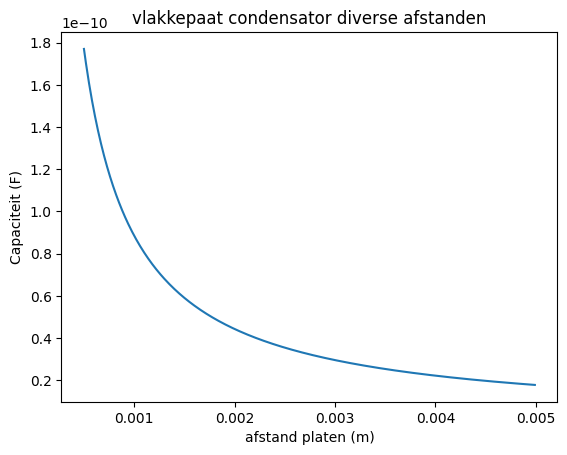

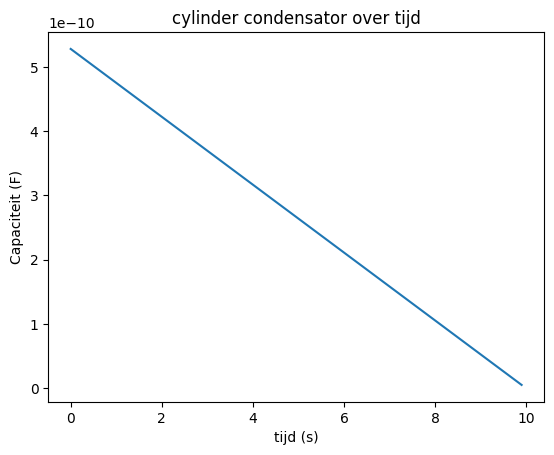

In [28]:
###
d_5f = np.arange(0.0005, 0.005 , 0.00001)
A_5f = 0.1**2
C_5f_1 = vlakkeplaat(A_5f, d_5f, epsilon0)

plt.figure()
plt.title("vlakkepaat condensator diverse afstanden")
plt.plot(d_5f,C_5f_1)
plt.xlabel("afstand platen (m)")
plt.ylabel("Capaciteit (F)")
plt.show()


R_in_5f = 0.009
R_out_5f = 0.01
t = np.arange(0,10,0.1)
L = (10-t)*0.1
C_5f_2 = cilinder(R_in_5f, R_out_5f, L, epsilon0)

plt.figure()
plt.title("cylinder condensator over tijd")
plt.plot(t,C_5f_2)
plt.xlabel("tijd (s)")
plt.ylabel("Capaciteit (F)")
plt.show()
###

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Sensor.jpeg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

![figure 5.1](figures/Sensor_schets_oplossing.jpeg)
 Hier is later nog in python de waarde voor de kurken aan toegevoegd.


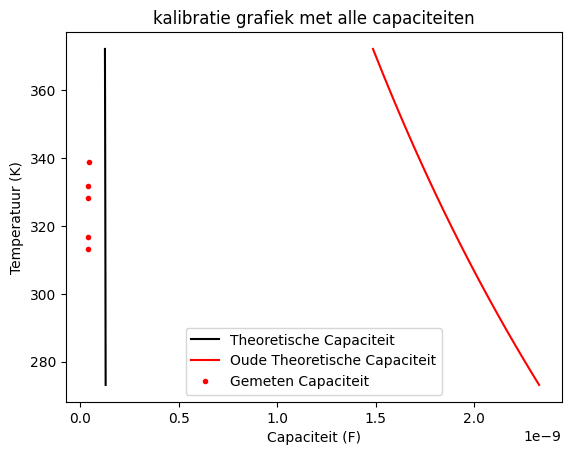

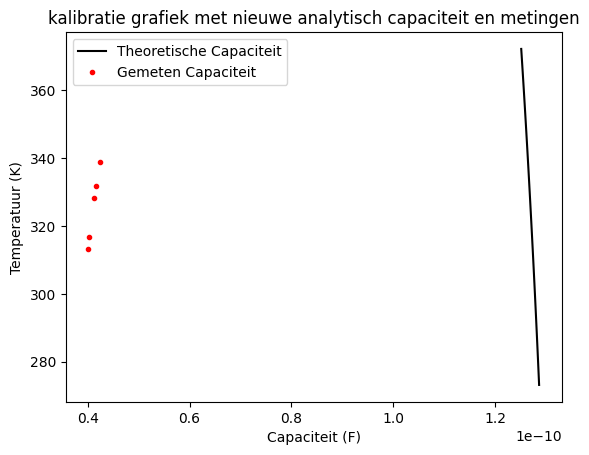

In [29]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
T = np.arange(273.15, 373.15, 1)

l = 0.1
b = 0.15
r_kurk = 0.015

d_water = 0.005
d_zakje = 0.0005
d_lucht = 0.00025

def epsilon_r_water_func(T):
    T = T - 273.15
    return 87.74 - 0.40008 * T + 9.398e-4 * T**2 - 1.41e-6 * T**3

epsilon_water = epsilon_r_water_func(T) * epsilon0
epsilon_zakje = 2.2*epsilon0
epsilon_kurk = 20*epsilon0
epsilon_lucht = epsilon_air

A_tot = l*b
A_kurk =  np.pi*r_kurk**2
A_water = A_tot - 3*A_kurk

C_water = vlakkeplaat(A_water, d_water, epsilon_water)
C_zakje_water = vlakkeplaat(A_water, d_zakje, epsilon_zakje)
C_zakje_kurk = vlakkeplaat(A_kurk, d_zakje, epsilon_zakje)
C_lucht_water = vlakkeplaat(A_water, d_lucht, epsilon_lucht)
C_lucht_kurk = vlakkeplaat(A_kurk, d_lucht, epsilon_lucht)
C_kurk = vlakkeplaat(A_kurk, d_water, epsilon_kurk)

C_tot_water = 1/(1/C_water + 2/C_zakje_water + 2/C_lucht_water)
C_tot_kurk = 3/(1/C_kurk + 2/C_zakje_kurk + 2/C_lucht_kurk)
C_tot = C_tot_kurk + C_tot_water

def epsilon_water_oud(T): #deze functie is de functie die de epsilon ten opzichte van temperatuur bepaald voor water.
    T = T - 273.15
    epsilon = (87.740-0.40008*T + 9.398e-4*T**2 - 1.41e-6 * T**3)*epsilon0 
    return epsilon

C_analytisch_oud = vlakkeplaat(A_tot, d_water, epsilon_water_oud(T))

gemeten_C = np.array([42.5,41.6,41.3,40.3,40.1]) * 10**-12
gemeten_T = np.array([65.6,58.7,55,43.6,40]) + 273.15

### Maak hier je plot
plt.figure()
plt.title("kalibratie grafiek met alle capaciteiten")
plt.plot(C_tot, T, "k-", label="Theoretische Capaciteit")
plt.plot(C_analytisch_oud, T, "r-", label="Oude Theoretische Capaciteit")
plt.plot(gemeten_C, gemeten_T, "r.", label="Gemeten Capaciteit")
plt.xlabel("Capaciteit (F)")
plt.ylabel("Temperatuur (K)")
plt.legend()
plt.show()

plt.figure()
plt.title("kalibratie grafiek met nieuwe analytisch capaciteit en metingen")
plt.plot(C_tot, T, "k-", label="Theoretische Capaciteit")
plt.plot(gemeten_C, gemeten_T, "r.", label="Gemeten Capaciteit")
plt.xlabel("Capaciteit (F)")
plt.ylabel("Temperatuur (K)")
plt.legend()
plt.show()

##### Antwoorden 6a
De kromme van de oude Capaciteit is veel hoger en heeft een hogere absolute afgeleiden, dit komt omdat de lagen behalve water tussen de geleidende platen niet zijn megenomen in de oude capaciteit. Dit zorgt er voor dat de verandering in de dielektrische konstante van het water veel meer effect heeft op de totale capaciteit van de sensor en de capaciteit veel hoger is dan in de realiteit. 

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [30]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [31]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Er zijn twee grote verschillen. Als eerst is de orde van grote, de voorspelde waardes zijn ongeveer vier keer zo groot. Een mogelijke voorspelling voor dit zou zijn dat de dieelektriche constante van de lagen tussen de platen lager zijn dan we hadden verwacht of dat de dikte van de lagen van bijvoorbeeld de zakjes of lucht groter zijn dan verwacht. Overigens zijn de genomen waardes al groot vergeleken met wat je zou verwachten. 

 Het andere verschil is belangrijker en dat is dat er een omgekeerd verband is. Wij hebben eigenlijk geen goed idee waarom dit het geval is we zijn de code meerdere keren langs gelopen en hebben niets kunnen vinden wat het zou kunnen veroorzaken. Het zou mogelijk de onnauwkeurigheid van de arduino kunnen zijn, aangezien de verandering in de capaciteit van de sensor relatief klein is. Ook zouden het externe factoren kunnen zijn die de verandering in de capaciteit meer zouden hebben beinvloed. Iets bedoemings waardigs is dat de functie voor de dielektrische constante de temperatuur in celsius gebruikt, maar als hij in kelvin wordt ingevuld lijkt het verband veel beter te kloppen, dit komt overigens niet overeen met hoe de functie is gemaakt of gebruikt in de gevonden bron (Malmberg & Maryott, 1956).

 Malmberg, C. G., & Maryott, A. A. (1956). Dielectric constant of water from 0 to 100 C. Journal of Research of the National Bureau of Standards, 56(1), 1. https://doi.org/10.6028/jres.056.001